<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2FkyleV/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [16]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [17]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1095/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1095/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


In [18]:
print(df.columns)

Index(['date', 'hour', 'minute', 'second', 'latitude', 'longitude',
       'correctedArea', 'CAUnc', 'uniqueID', 'CYCLE', 'survey'],
      dtype='object')


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


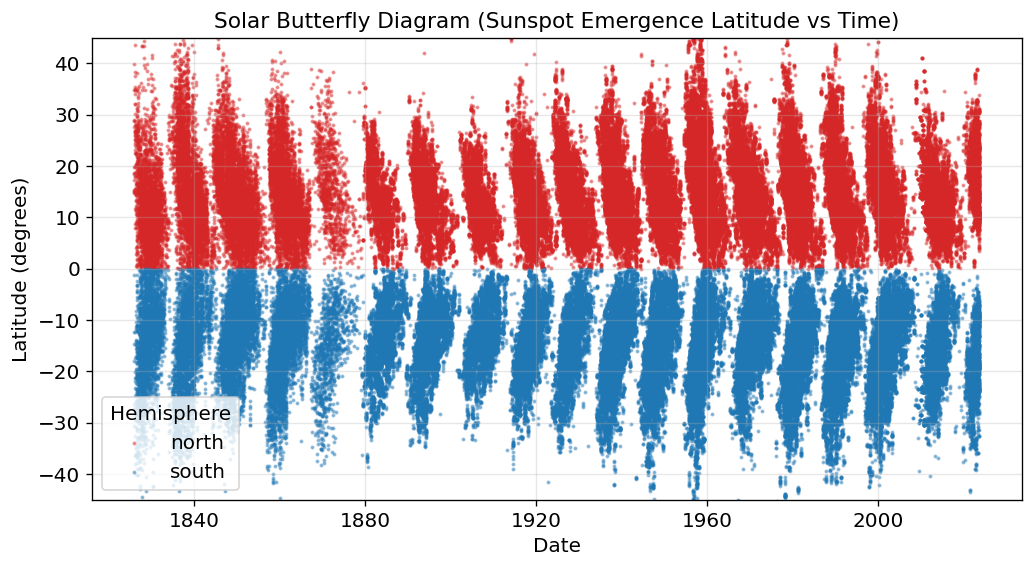

In [19]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


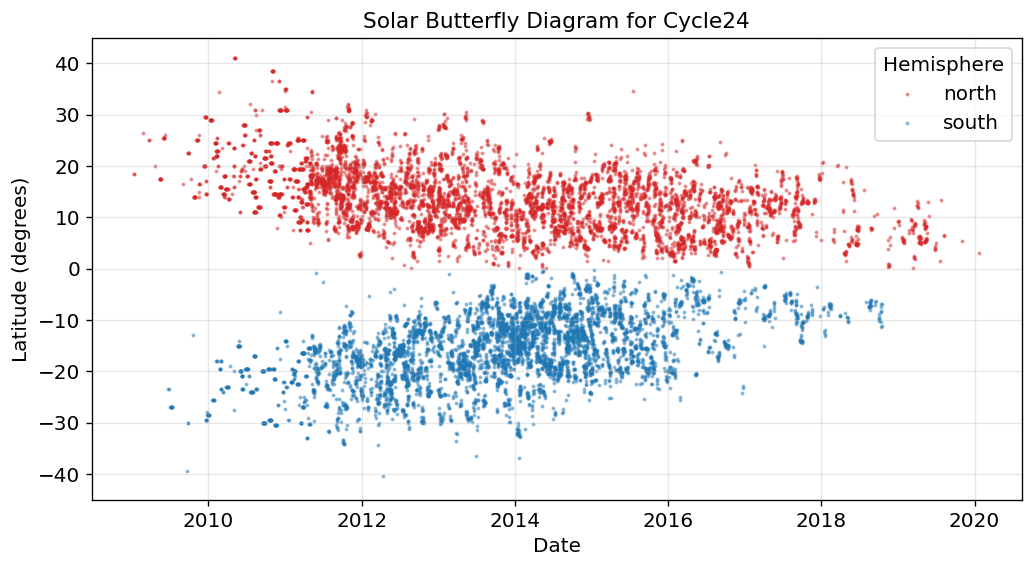

In [27]:
# Your code here: Visualize a single solar cycle

# hemispheres are already set in previous code block
cycle = 24
df_cycle = df[df['CYCLE'] == cycle].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title(f"Solar Butterfly Diagram for Cycle{cycle}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

#### Observations
Regardless of the cycle number, they all seem to have a similar shape with active regions starting at larger latitudes and converging towards the equator.
However, some cycles have smaller amplitudes(14), while others are larger(19)

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


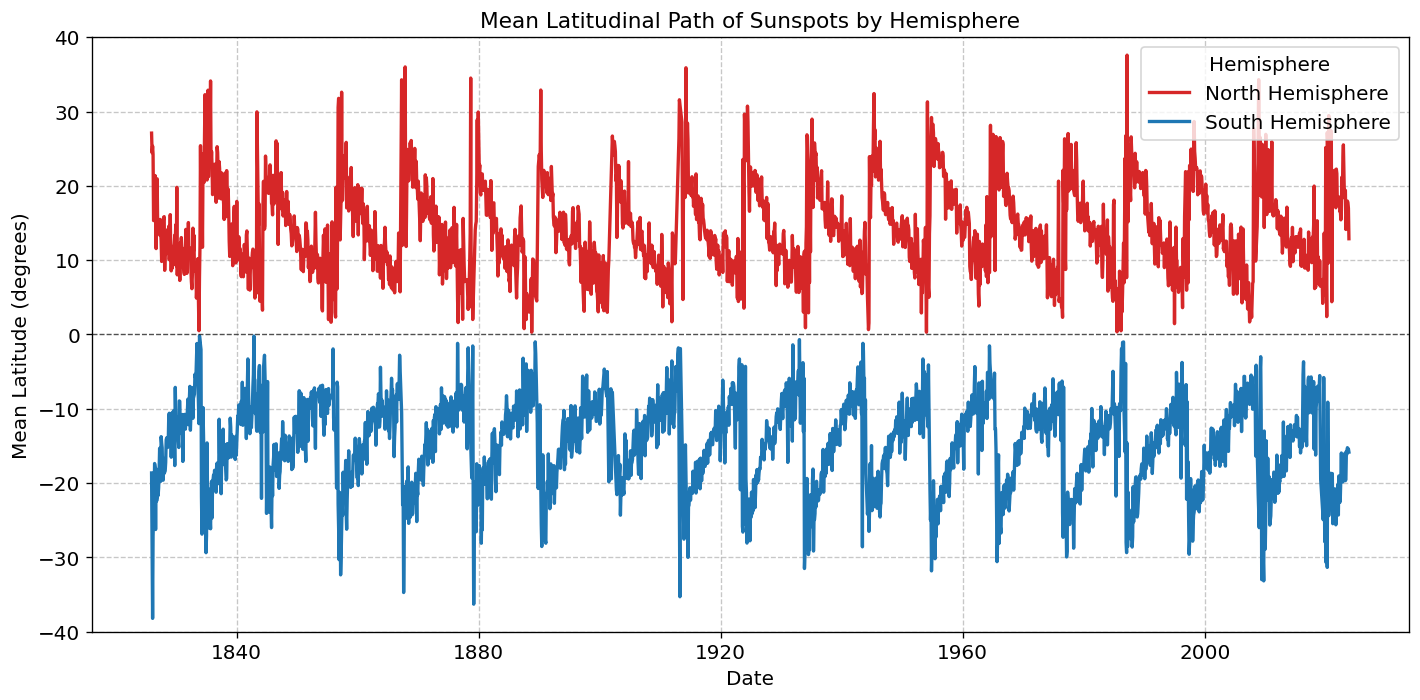

In [34]:
# Your code here: Calculate and plot mean latitudinal paths
df_monthly_mean = df.groupby(['hemisphere', pd.Grouper(key='date', freq='ME')])['latitude'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for hemi, group in df_monthly_mean.groupby('hemisphere'):
    ax.plot(group['date'], group['latitude'], color=colors[hemi], label=f'{hemi.capitalize()} Hemisphere', linewidth=2)

ax.set_title('Mean Latitudinal Path of Sunspots by Hemisphere')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Latitude (degrees)')
ax.legend(title='Hemisphere')
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_ylim(-40, 40) # Set appropriate y-limits
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6) # Add equator line
plt.tight_layout()
plt.show()

#### Discussion: What does this tell us about the solar cycle's evolution?

This plot shows the same "wing" pattern as the previous butterfly diagrams, which tells us how active regions move throughout a solar cycle. This movement is symmetrical across the equator with active regions starting in higher latitudes and migrating toward the equator. They then disappear for a short period of time, and then reappear at a high latitude again, restarting the cycle. It also shows that each solar cycle takes approximately the same amount of time(~11 years). Although each solar cycle follows similar behavior, some properties like the starting latitude tend to vary between cycles.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


#### Gemini Response
To effectively prompt an AI assistant for learning machine learning and solar physics, consider these strategies:

1. Be Specific and Clear: Instead of a vague question like 'Tell me about machine learning,' try 'Explain the concept of backpropagation in neural networks, including its mathematical foundation and a simple example.' For solar physics, 'Describe the process of solar flare formation, focusing on the magnetic reconnection theory.'

1. Break Down Complex Topics: For broad subjects, ask about sub-topics individually. For example, rather than 'Teach me solar physics,' start with 'What are sunspots and how do they form?' then move to 'Explain the solar cycle's impact on Earth's climate.'

1. Specify the Level of Detail: Let the AI know your current understanding. You can say 'Explain [concept] as if I'm a beginner,' or 'Provide an advanced explanation of [concept] suitable for someone with a background in [related field].'

1. Request Analogies and Examples: Abstract concepts become clearer with good analogies and concrete examples. Ask for 'an analogy to understand gradient descent' or 'a real-world example of how convolutional neural networks are used.'

1. Ask for Step-by-Step Explanations: For processes or algorithms, ask the AI to walk you through it step-by-step. 'Explain the steps involved in training a support vector machine.'

1. Request Code Examples (for ML): When learning machine learning, code examples are invaluable. Ask for 'a Python code snippet to implement a simple linear regression model using scikit-learn' or 'how to visualize sunspot data using matplotlib and pandas.'

1. Compare and Contrast: To deepen understanding, ask the AI to compare related concepts. 'What are the key differences between supervised and unsupervised learning?' or 'Compare the properties of the solar corona and photosphere.'

1. Ask 'Why' and 'How': Don't just settle for 'what.' Ask 'Why is this important?' or 'How does this work?' For example, 'Why is feature scaling important in machine learning?' or 'How do scientists measure the Sun's magnetic field?'

1. Iterate and Follow Up: If an explanation isn't clear, ask for clarification. 'Can you rephrase that in simpler terms?' or 'Could you elaborate on the role of [specific term] in that explanation?'

1. Define Your Learning Goal: Having a clear goal helps the AI tailor its responses. Are you preparing for an exam, working on a project, or just curious?

By being precise and interactive with your prompts, you can guide the AI to provide highly relevant and educational responses.


#### My reflection
The AI gave a very detailed response, so I want to reflect on some of the points that stood out to me.

1. From my previous experience using AI assistants, this is essential in getting desired outputs. They often make assumptions that shouldn't be made, which I then have to correct and clarify.

2) I will most likely be seeing a lot of new material for the first time, so having a clear breakdown of the more complex topics will be invaluable.

8. It is definitely important to not take AI responses at surface value. Asking for more information forces us to learn the material instead of just taking their results without understanding why. It can also help us or the AI notice any mistakes it made.


## AI responses from Gemini


how can i filter a pandas dataframe by a column? in my case, i have a df that has a cycle column. i only want rows with cycle 24
You can filter a pandas DataFrame by a column using boolean indexing. Here's how you can filter your df to show only rows where the 'CYCLE' column is equal to 24:


***how can i print all of the columns in a dataframe
You can print all columns of a DataFrame by adjusting pandas' display options. Here's how you can do it:***

df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False) df.rename(columns={"year_month_day": "date"}, inplace=True) # Keep only rows with valid latitude (sunspot groups) df = df[df["latitude"].notna()].copy() # Quick sanity check df[["date", "latitude", "CYCLE"]].head() going off of this code, can you give me a line that prints the columns in the dataframe
Certainly! You can print all the column names of your DataFrame df using the .columns attribute. Here's the line of code:

The code executed successfully and printed all the columns in your DataFrame df. The columns are: 'date', 'hour', 'minute', 'second', 'latitude', 'longitude', 'correctedArea', 'CAUnc', 'uniqueID', 'CYCLE', and 'survey'.


***what does df.groupby('col') do?***

In pandas, df.groupby('col') is a powerful method used for grouping rows of a DataFrame together based on the unique values in a specified column (in this case, 'col').

Think of it like this:

Splitting the data: It conceptually splits the DataFrame into multiple smaller DataFrames, where each smaller DataFrame contains only rows that have the same value in the 'col' column.

Applying a function: After grouping, you typically apply some aggregation function (like sum(), mean(), count(), min(), max(), size(), etc.) to each of these smaller DataFrames.

Combining the results: Finally, it combines the results of these operations back into a single DataFrame or Series.
For example, if you have a DataFrame of sales and you groupby('product_category'), you can then calculate the total sales (.sum()) for each product category. In your case, df.groupby("hemisphere") would group your sunspot data into two groups: 'north' and 'south', allowing you to analyze each hemisphere separately.


***Calculate mean latitudinal paths for each hemisphere***

I will calculate the mean latitudinal paths for each hemisphere by grouping the data by hemisphere and then resampling it monthly to get the average latitude. Then, I will plot these paths to visualize the solar cycle's evolution.

Great! The plot showing the 'Mean Latitudinal Path of Sunspots by Hemisphere' has been successfully generated. This visualization clearly illustrates how sunspots emerge at higher latitudes at the beginning of a solar cycle and gradually migrate towards the equator, a phenomenon described by Spörer's law. You can observe the distinct paths for the northern and southern hemispheres over time, highlighting the cyclic nature of sunspot activity.

Regarding the output, you also received a FutureWarning that 'M' is deprecated for frequency in pd.Grouper and suggests using 'ME' instead. This is a warning, not an error, meaning your code still ran and produced the plot. However, it's good practice to update it to 'ME' to ensure compatibility with future pandas versions. I will update the code to address this warning.

The plot has been successfully regenerated with the corrected frequency 'ME', and the FutureWarning has been resolved. The visualization of the mean latitudinal path of sunspots for each hemisphere should be visible above.


***Ask AI to explain Spörer's law in solar physics***

Explain Spörer's law in solar physics

Spörer's Law, named after the German astronomer Gustav Spörer, describes the systematic migration of sunspots during the course of a solar cycle. Essentially, at the beginning of a new solar cycle, sunspots tend to emerge at higher latitudes (around 30-35 degrees north and south of the equator). As the solar cycle progresses towards its maximum, new sunspots appear closer and closer to the Sun's equator (around 15 degrees). Towards the end of the cycle, sunspots are typically found at very low latitudes (around 5 degrees) before the cycle fades and a new one begins, with sunspots again appearing at higher latitudes.

This phenomenon is clearly visible in the butterfly diagram, where the sunspots form two 'wings' that spread from higher latitudes down towards the equator over time, mimicking the shape of a butterfly's wings. This pattern reflects the complex interplay of magnetic fields within the Sun's interior, which are thought to be generated by a solar dynamo.


***df_monthly_mean = df.groupby(['hemisphere', pd.Grouper(key='date', freq='ME')])['latitude'].mean().reset_index() break down what this line is doing***

Certainly! Let's break down this line of code step by step:

df.groupby(['hemisphere', pd.Grouper(key='date', freq='ME')]): This is the core grouping operation. It groups the DataFrame df by two criteria:

'hemisphere': It groups rows based on whether they belong to the 'north' or 'south' hemisphere.

pd.Grouper(key='date', freq='ME'): This is a special grouper used to group by time. It takes the 'date' column and groups the data by the end of each month (freq='ME'). So, for each hemisphere, it creates monthly groups of data.
['latitude'].mean(): After grouping, this part selects the 'latitude' column from each group and calculates the mean (average) latitude for all entries within that group (i.e., for each hemisphere and month combination).

.reset_index(): By default, groupby() operations return a Series (or DataFrame) with the grouping keys (in this case, 'hemisphere' and 'date') as the index. reset_index() converts these index levels back into regular columns, making hemisphere and date proper columns in the resulting df_monthly_mean DataFrame.